# Seattle Permit Predictor — XGBoost Model (with Comment Features)
*5-Fold Cross-Validated XGBoost | Target: `log(1 + totaldaysplanreview)`*

**This notebook trains an XGBoost (Extreme Gradient Boosting) regressor on the same broad modeling population and comment-enriched feature set as `PermitPredictor_RF_Comments.ipynb`, allowing direct apples-to-apples comparison.**

**Why XGBoost over Random Forest:**
- Gradient boosting builds trees sequentially, each correcting the errors of the previous — better at capturing complex nonlinear patterns
- Handles high null rates (95% on comment features) natively without requiring a separate imputation step
- Typically outperforms random forest on tabular data with mixed feature types
- `learning_rate` and `subsample` parameters provide additional regularization levers

**Feature set (identical to RF Comments model):**
- Categorical: `permittypedesc`, `permitclass`, `zone_family`
- Base numeric: `log_estprojectcost`, `log_housingunitsadded`, `latitude`, `longitude`
- Comment features (9): `comment_max_cycle`, `comment_n_distinct_cycles`, `comment_n_rows`, `comment_n_subjects`, `comment_n_review_types`, `comment_has_structural`, `comment_has_eca`, `comment_has_design_review`, `comment_resubmit_rate`

**Modeling population:** All 14,201 completed post-2019 permits with recorded review times.

## 0. Install & Import

In [4]:
import sys
!{sys.executable} -m pip install xgboost --quiet
print('xgboost installed.')

xgboost installed.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\flori\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
import datetime
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
OUTPUT_DIR   = r'C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\output' + '\\'
DATA_DIR     = r'C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\data' + '\\'
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Join Data

In [6]:
df = pd.read_csv(f'{DATA_DIR}master_dataset.csv')
print(f'Master dataset   : {len(df):,} rows')

comment_features = pd.read_csv(f'{OUTPUT_DIR}comment_features.csv')
print(f'Comment features : {len(comment_features):,} rows × {len(comment_features.columns)} columns')

df = df.merge(comment_features, on='permitnum', how='left')

has_comments = df['comment_n_rows'].notna().sum()
print(f'\nAfter join       : {len(df):,} rows')
print(f'  With comments  : {has_comments:,} ({has_comments/len(df)*100:.1f}%)')
print(f'  Without        : {len(df)-has_comments:,} ({(len(df)-has_comments)/len(df)*100:.1f}%)')
print(f'\nReview time stats (days):')
print(df['totaldaysplanreview'].describe().round(1))

Master dataset   : 14,201 rows
Comment features : 707 rows × 46 columns

After join       : 14,201 rows
  With comments  : 665 (4.7%)
  Without        : 13,536 (95.3%)

Review time stats (days):
count    14201.0
mean       153.9
std        155.0
min          3.0
25%         52.0
50%        103.0
75%        202.0
max       1094.0
Name: totaldaysplanreview, dtype: float64


## 2. Feature Selection & Preprocessing

XGBoost handles missing values natively — it learns the optimal direction to send null values at each split. However, categorical features still need to be encoded since XGBoost expects numeric inputs. We use OrdinalEncoder (same as the random forest model) for consistency and direct comparability.

In [7]:
CAT_FEATURES = ['permittypedesc', 'permitclass', 'zone_family']

BASE_NUM_FEATURES = [
    'log_estprojectcost',
    'log_housingunitsadded',
    'latitude',
    'longitude',
]

COMMENT_FEATURES = [
    'comment_max_cycle',
    'comment_n_distinct_cycles',
    'comment_n_rows',
    'comment_n_subjects',
    'comment_n_review_types',
    'comment_has_structural',
    'comment_has_eca',
    'comment_has_design_review',
    'comment_resubmit_rate',
]

NUM_FEATURES = BASE_NUM_FEATURES + COMMENT_FEATURES
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET       = 'log_target'

for col in CAT_FEATURES:
    df[col] = df[col].fillna('Unknown')

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print('Feature set:')
print(f'  Categorical ({len(CAT_FEATURES)})    : {CAT_FEATURES}')
print(f'  Base numeric ({len(BASE_NUM_FEATURES)})   : {BASE_NUM_FEATURES}')
print(f'  Comment ({len(COMMENT_FEATURES)})        : {COMMENT_FEATURES}')
print(f'\nX shape: {X.shape} | y shape: {y.shape}')
print(f'\nNull counts per feature:')
print(X.isnull().sum())

Feature set:
  Categorical (3)    : ['permittypedesc', 'permitclass', 'zone_family']
  Base numeric (4)   : ['log_estprojectcost', 'log_housingunitsadded', 'latitude', 'longitude']
  Comment (9)        : ['comment_max_cycle', 'comment_n_distinct_cycles', 'comment_n_rows', 'comment_n_subjects', 'comment_n_review_types', 'comment_has_structural', 'comment_has_eca', 'comment_has_design_review', 'comment_resubmit_rate']

X shape: (14201, 16) | y shape: (14201,)

Null counts per feature:
permittypedesc                   0
permitclass                      0
zone_family                      0
log_estprojectcost              45
log_housingunitsadded          237
latitude                        19
longitude                       19
comment_max_cycle            13536
comment_n_distinct_cycles    13536
comment_n_rows               13536
comment_n_subjects           13536
comment_n_review_types       13536
comment_has_structural       13536
comment_has_eca              13536
comment_has_design_rev

In [8]:
# Categorical: OrdinalEncoder (XGBoost needs numeric input)
# Numeric: pass through — XGBoost handles nulls natively via its
# built-in missing value handler, no imputation needed
cat_pipe = Pipeline([
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, CAT_FEATURES),
    ('num', 'passthrough', NUM_FEATURES),
], remainder='drop')

print('Preprocessor configured.')
print('  Note: numeric features passed through without imputation —')
print('  XGBoost handles null values natively at each tree split.')

Preprocessor configured.
  Note: numeric features passed through without imputation —
  XGBoost handles null values natively at each tree split.


## 3. Baseline XGBoost — 5-Fold Cross Validation

Initial model with sensible defaults as a baseline before tuning.

In [9]:
xgb_baseline = XGBRegressor(
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbosity         = 0,
)

model_pipeline = Pipeline([
    ('prep', preprocessor),
    ('xgb', xgb_baseline)
])

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_pipeline.fit(X_train, y_train)
    y_pred_log = model_pipeline.predict(X_val)

    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
    mae_log  = mean_absolute_error(y_val, y_pred_log)
    r2       = r2_score(y_val, y_pred_log)

    y_val_days  = np.expm1(y_val)
    y_pred_days = np.expm1(y_pred_log)
    rmse_days   = np.sqrt(mean_squared_error(y_val_days, y_pred_days))
    mae_days    = mean_absolute_error(y_val_days, y_pred_days)

    fold_results.append({
        'fold': fold, 'rmse_log': rmse_log, 'mae_log': mae_log,
        'r2': r2, 'rmse_days': rmse_days, 'mae_days': mae_days
    })
    print(f'Fold {fold} | R²={r2:.4f} | RMSE(log)={rmse_log:.4f} | MAE(days)={mae_days:.1f}')

results_df = pd.DataFrame(fold_results)
print('\n--- 5-Fold Cross Validation Summary (Baseline XGBoost) ---')
print(results_df.drop('fold', axis=1).describe().loc[['mean', 'std']].round(4))

Fold 1 | R²=0.3589 | RMSE(log)=0.7411 | MAE(days)=73.0
Fold 2 | R²=0.3627 | RMSE(log)=0.7449 | MAE(days)=77.2
Fold 3 | R²=0.3420 | RMSE(log)=0.7516 | MAE(days)=77.3
Fold 4 | R²=0.3821 | RMSE(log)=0.7327 | MAE(days)=75.2
Fold 5 | R²=0.3758 | RMSE(log)=0.7554 | MAE(days)=74.1

--- 5-Fold Cross Validation Summary (Baseline XGBoost) ---
      rmse_log  mae_log      r2  rmse_days  mae_days
mean    0.7451   0.5712  0.3643   129.7972   75.3551
std     0.0089   0.0066  0.0156     5.1624    1.8936


## 4. Hyperparameter Tuning — Grid Search

XGBoost is most sensitive to `learning_rate`, `max_depth`, `subsample`, and `colsample_bytree`. The grid is kept focused to balance tuning quality against runtime. Higher `n_estimators` with lower `learning_rate` generally improves XGBoost performance.

In [10]:
param_grid = {
    'xgb__n_estimators':     [300, 500],
    'xgb__learning_rate':    [0.03, 0.05, 0.1],
    'xgb__max_depth':        [4, 6, 8],
    'xgb__subsample':        [0.7, 0.9],
    'xgb__colsample_bytree': [0.7, 0.9],
}

grid_search = GridSearchCV(
    estimator=Pipeline([
        ('prep', preprocessor),
        ('xgb', XGBRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        ))
    ]),
    param_grid=param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print('\nBest parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest cross validation RMSE (log scale): {-grid_search.best_score_:.4f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best parameters:
  xgb__colsample_bytree: 0.7
  xgb__learning_rate: 0.03
  xgb__max_depth: 6
  xgb__n_estimators: 300
  xgb__subsample: 0.9

Best cross validation RMSE (log scale): 0.7419


## 5. Tuned XGBoost — 5-Fold Cross Validation

In [11]:
best_params = {k.replace('xgb__', ''): v for k, v in grid_search.best_params_.items()}

xgb_tuned = XGBRegressor(
    **best_params,
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    verbosity    = 0,
)

tuned_pipeline = Pipeline([
    ('prep', preprocessor),
    ('xgb', xgb_tuned)
])

tuned_results = []
oof_preds = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    tuned_pipeline.fit(X_train, y_train)
    y_pred_log = tuned_pipeline.predict(X_val)
    oof_preds[val_idx] = y_pred_log

    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
    mae_log  = mean_absolute_error(y_val, y_pred_log)
    r2       = r2_score(y_val, y_pred_log)

    y_val_days  = np.expm1(y_val)
    y_pred_days = np.expm1(y_pred_log)
    rmse_days   = np.sqrt(mean_squared_error(y_val_days, y_pred_days))
    mae_days    = mean_absolute_error(y_val_days, y_pred_days)

    tuned_results.append({
        'fold': fold, 'rmse_log': rmse_log, 'mae_log': mae_log,
        'r2': r2, 'rmse_days': rmse_days, 'mae_days': mae_days
    })
    print(f'Fold {fold} | R²={r2:.4f} | RMSE(log)={rmse_log:.4f} | MAE(days)={mae_days:.1f}')

tuned_df = pd.DataFrame(tuned_results)
print('\n--- 5-Fold Cross Validation Summary (Tuned XGBoost) ---')
print(tuned_df.drop('fold', axis=1).describe().loc[['mean', 'std']].round(4))

Fold 1 | R²=0.3633 | RMSE(log)=0.7386 | MAE(days)=73.2
Fold 2 | R²=0.3699 | RMSE(log)=0.7406 | MAE(days)=77.0
Fold 3 | R²=0.3536 | RMSE(log)=0.7450 | MAE(days)=77.1
Fold 4 | R²=0.3825 | RMSE(log)=0.7325 | MAE(days)=75.6
Fold 5 | R²=0.3816 | RMSE(log)=0.7519 | MAE(days)=73.9

--- 5-Fold Cross Validation Summary (Tuned XGBoost) ---
      rmse_log  mae_log      r2  rmse_days  mae_days
mean    0.7417   0.5688  0.3702   130.8448   75.3848
std     0.0073   0.0050  0.0123     4.6859    1.7787


## 6. Evaluation Plots

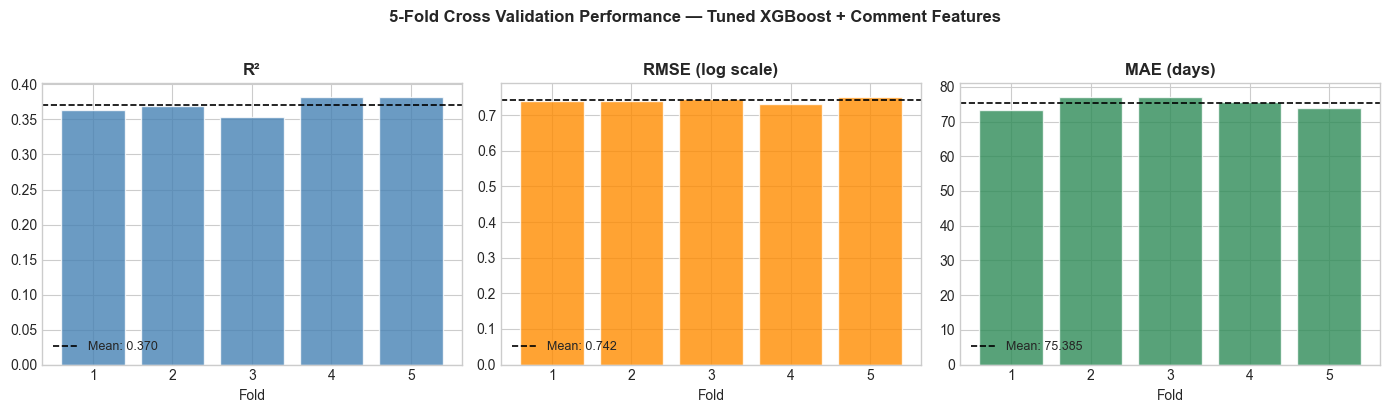

Saved: cv_metrics_per_fold_xgb.png


In [12]:
# --- Per-fold metrics bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [('r2', 'R²', 'steelblue'), ('rmse_log', 'RMSE (log scale)', 'darkorange'), ('mae_days', 'MAE (days)', 'seagreen')]

for ax, (col, label, color) in zip(axes, metrics):
    ax.bar(tuned_df['fold'], tuned_df[col], color=color, alpha=0.8, edgecolor='white')
    mean_val = tuned_df[col].mean()
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.3f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_xticks(tuned_df['fold'])
    ax.legend(fontsize=9)

plt.suptitle('5-Fold Cross Validation Performance — Tuned XGBoost + Comment Features', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}cv_metrics_per_fold_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cv_metrics_per_fold_xgb.png')

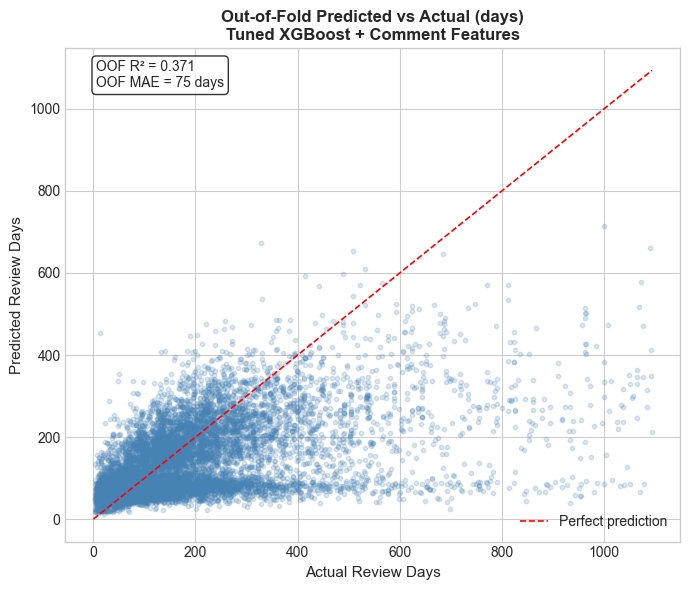

Saved: oof_pred_vs_actual_xgb.png


In [13]:
# --- Out-of-fold predicted vs actual ---
actual_days = np.expm1(y.values)
pred_days   = np.expm1(oof_preds)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(actual_days, pred_days, alpha=0.2, s=10, color='steelblue', rasterized=True)
max_val = max(actual_days.max(), pred_days.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual Review Days', fontsize=11)
ax.set_ylabel('Predicted Review Days', fontsize=11)
ax.set_title('Out-of-Fold Predicted vs Actual (days)\nTuned XGBoost + Comment Features', fontsize=12, fontweight='bold')
ax.legend()

overall_r2  = r2_score(y.values, oof_preds)
overall_mae = mean_absolute_error(actual_days, pred_days)
ax.text(0.05, 0.92, f'OOF R² = {overall_r2:.3f}\nOOF MAE = {overall_mae:.0f} days',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}oof_pred_vs_actual_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: oof_pred_vs_actual_xgb.png')

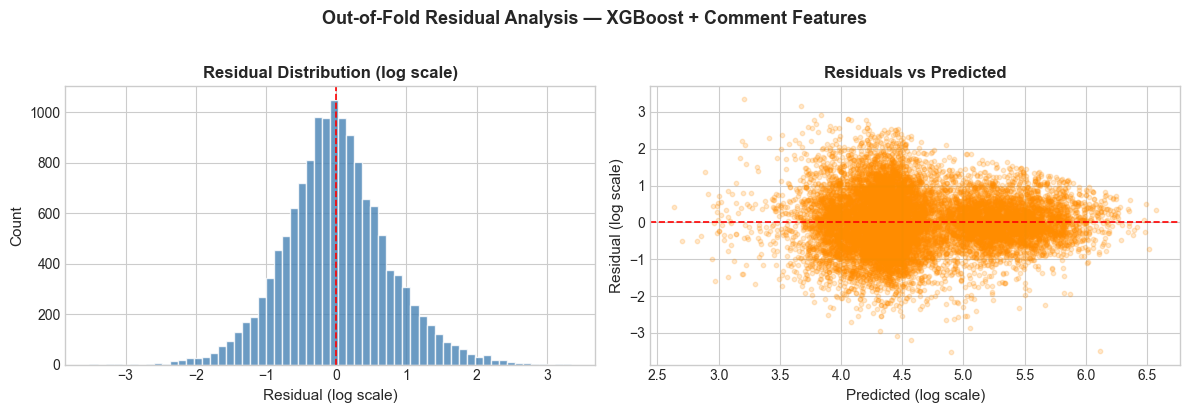

Saved: residual_analysis_xgb.png


In [14]:
# --- Residual analysis ---
residuals_log = y.values - oof_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals_log, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_xlabel('Residual (log scale)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Residual Distribution (log scale)', fontsize=12, fontweight='bold')

axes[1].scatter(oof_preds, residuals_log, alpha=0.2, s=10, color='darkorange', rasterized=True)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Predicted (log scale)', fontsize=11)
axes[1].set_ylabel('Residual (log scale)', fontsize=11)
axes[1].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')

plt.suptitle('Out-of-Fold Residual Analysis — XGBoost + Comment Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residual_analysis_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: residual_analysis_xgb.png')

## 7. Feature Importance

XGBoost provides two importance metrics. We report both:
- **Weight** — number of times a feature is used to split across all trees (frequency)
- **Gain** — average improvement in loss when a feature is used to split (quality) — this is the more informative metric

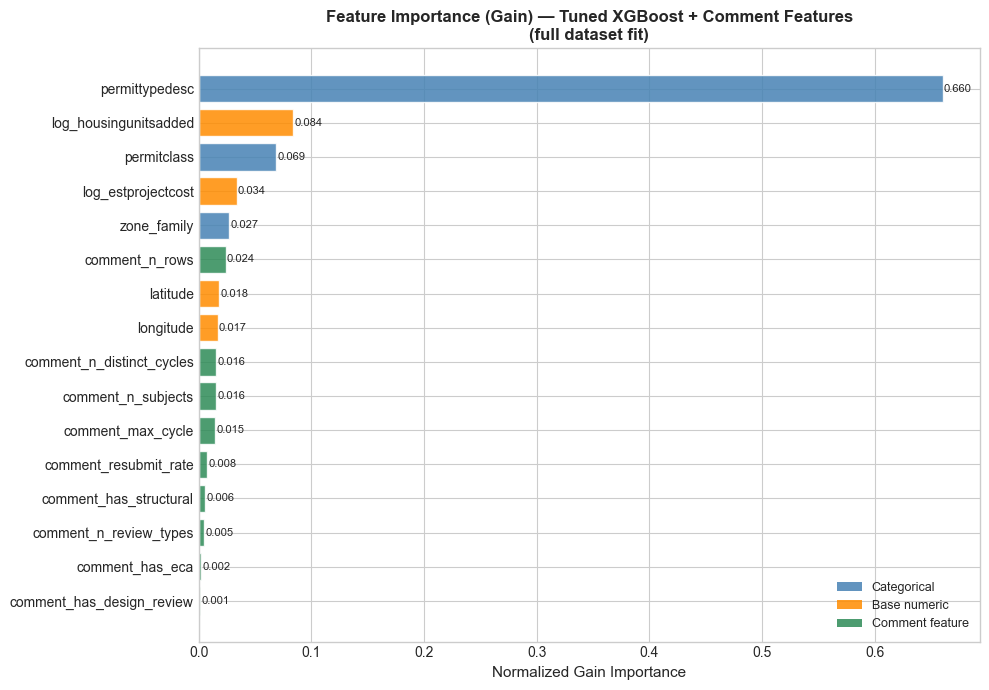

Saved: feature_importance_xgb.png

                  feature         type  gain_norm
           permittypedesc  categorical   0.660467
    log_housingunitsadded base numeric   0.084113
              permitclass  categorical   0.068800
       log_estprojectcost base numeric   0.033647
              zone_family  categorical   0.027244
           comment_n_rows      comment   0.023924
                 latitude base numeric   0.017900
                longitude base numeric   0.016815
comment_n_distinct_cycles      comment   0.015533
       comment_n_subjects      comment   0.015529
        comment_max_cycle      comment   0.014598
    comment_resubmit_rate      comment   0.007523
   comment_has_structural      comment   0.005700
   comment_n_review_types      comment   0.004567
          comment_has_eca      comment   0.002368
comment_has_design_review      comment   0.001272


In [15]:
tuned_pipeline.fit(X, y)

xgb_model     = tuned_pipeline.named_steps['xgb']
feature_names = ALL_FEATURES

# Gain importance (most informative)
gain_scores = xgb_model.get_booster().get_score(importance_type='gain')
# Map f0, f1... back to feature names
gain_df = pd.DataFrame([
    {'feature': feature_names[int(k[1:])], 'gain': v}
    for k, v in gain_scores.items()
]).sort_values('gain', ascending=True)

# Normalize gain to sum to 1 for comparability
gain_df['gain_norm'] = gain_df['gain'] / gain_df['gain'].sum()
gain_df['type'] = gain_df['feature'].apply(
    lambda f: 'categorical' if f in CAT_FEATURES else ('comment' if f in COMMENT_FEATURES else 'base numeric')
)

color_map = {'categorical': 'steelblue', 'base numeric': 'darkorange', 'comment': 'seagreen'}
colors = [color_map[t] for t in gain_df['type']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(gain_df['feature'], gain_df['gain_norm'], color=colors, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, gain_df['gain_norm']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue',  alpha=0.85, label='Categorical'),
    Patch(facecolor='darkorange', alpha=0.85, label='Base numeric'),
    Patch(facecolor='seagreen',   alpha=0.85, label='Comment feature'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_xlabel('Normalized Gain Importance', fontsize=11)
ax.set_title('Feature Importance (Gain) — Tuned XGBoost + Comment Features\n(full dataset fit)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance_xgb.png')
print()
print(gain_df.sort_values('gain_norm', ascending=False)[['feature','type','gain_norm']].to_string(index=False))

## 8. Model Comparison

Side-by-side comparison of all models trained so far.

In [16]:
oof_r2_xgb   = r2_score(y.values, oof_preds)
oof_mae_xgb  = mean_absolute_error(np.expm1(y.values), np.expm1(oof_preds))
oof_rmse_xgb = np.sqrt(mean_squared_error(y.values, oof_preds))

comparison = pd.DataFrame([
    {'Model': 'RF — Broad',              'OOF R²': 0.3613, 'OOF RMSE (log)': 0.7472, 'OOF MAE (days)': 76.0},
    {'Model': 'RF — Broad + Comments',   'OOF R²': 0.3691, 'OOF RMSE (log)': 0.7426, 'OOF MAE (days)': 74.6},
    {'Model': 'XGB — Broad + Comments',  'OOF R²': round(oof_r2_xgb, 4), 'OOF RMSE (log)': round(oof_rmse_xgb, 4), 'OOF MAE (days)': round(oof_mae_xgb, 1)},
])

print('=== Model Comparison ===')
print(comparison.to_string(index=False))

=== Model Comparison ===
                 Model  OOF R²  OOF RMSE (log)  OOF MAE (days)
            RF — Broad  0.3613          0.7472            76.0
 RF — Broad + Comments  0.3691          0.7426            74.6
XGB — Broad + Comments  0.3707          0.7417            75.4


## 9. Sanity Check — Predicted vs Actual

In [17]:
df_pred = df.copy()
for col in CAT_FEATURES:
    df_pred[col] = df_pred[col].fillna('Unknown')

df_pred['predicted_log']  = tuned_pipeline.predict(df_pred[ALL_FEATURES])
df_pred['predicted_days'] = np.expm1(df_pred['predicted_log'])
df_pred['actual_days']    = np.expm1(df_pred['log_target'])

print('=== Median Predicted vs Actual Days by Permit Type ===')
pt = df_pred.groupby('permittypedesc').agg(
    n=('actual_days', 'count'),
    actual_median=('actual_days', 'median'),
    predicted_median=('predicted_days', 'median')
).round(1).sort_values('actual_median', ascending=False)
print(pt.to_string())

print('\n=== Median Predicted vs Actual Days by Permit Class ===')
pc = df_pred.groupby('permitclass').agg(
    n=('actual_days', 'count'),
    actual_median=('actual_days', 'median'),
    predicted_median=('predicted_days', 'median')
).round(1).sort_values('actual_median', ascending=False)
print(pc.to_string())

=== Median Predicted vs Actual Days by Permit Type ===
                                          n  actual_median  predicted_median
permittypedesc                                                              
New                                    4028          216.0        212.899994
Change of Use Only - No Construction     27           97.0         74.800003
Unknown                                   7           83.0         96.699997
Addition/Alteration                   10101           72.0         76.199997
Demolition                               37           62.0         66.300003
Deconstruction                            1           23.0         50.799999

=== Median Predicted vs Actual Days by Permit Class ===
                          n  actual_median  predicted_median
permitclass                                                 
Multifamily             861          295.0        302.500000
Institutional             5          259.0        158.500000
Vacant Land              19 

## 10. Inference Function

In [18]:
def predict_permit_review_time(
    permittypedesc: str,
    permitclass: str,
    zone_family: str,
    estprojectcost: float = None,
    housingunitsadded: float = None,
    latitude: float = None,
    longitude: float = None,
    comment_max_cycle: float = None,
    comment_n_distinct_cycles: float = None,
    comment_n_rows: float = None,
    comment_n_subjects: float = None,
    comment_n_review_types: float = None,
    comment_has_structural: float = None,
    comment_has_eca: float = None,
    comment_has_design_review: float = None,
    comment_resubmit_rate: float = None,
    pipeline=None,
    n_bootstrap_ci: bool = True,
    n_bootstrap: int = 200,
) -> dict:
    """
    Predict permit review time using the tuned XGBoost pipeline.
    Comment features are optional — XGBoost handles nulls natively.
    Confidence interval is derived via bootstrap sampling of training predictions.

    Parameters
    ----------
    permittypedesc    : e.g. 'New', 'Addition/Alteration'
    permitclass       : e.g. 'Single Family/Duplex', 'Multifamily', 'Commercial'
    zone_family       : e.g. 'SF', 'NR', 'LR'
    estprojectcost    : estimated project cost in dollars
    housingunitsadded : number of units added
    latitude          : decimal degrees
    longitude         : decimal degrees
    comment_*         : comment-derived features (all optional)
    n_bootstrap_ci    : if True, derive 80% CI via bootstrap
    n_bootstrap       : number of bootstrap samples for CI

    Returns
    -------
    dict: predicted_days, ci_low_days, ci_high_days, predicted_log
    """
    if pipeline is None:
        pipeline = tuned_pipeline

    row = pd.DataFrame([{
        'permittypedesc':            permittypedesc,
        'permitclass':               permitclass,
        'zone_family':               zone_family,
        'log_estprojectcost':        np.log1p(estprojectcost)    if estprojectcost    is not None else np.nan,
        'log_housingunitsadded':     np.log1p(housingunitsadded) if housingunitsadded is not None else np.nan,
        'latitude':                  latitude   if latitude   is not None else np.nan,
        'longitude':                 longitude  if longitude  is not None else np.nan,
        'comment_max_cycle':         comment_max_cycle         if comment_max_cycle         is not None else np.nan,
        'comment_n_distinct_cycles': comment_n_distinct_cycles if comment_n_distinct_cycles is not None else np.nan,
        'comment_n_rows':            comment_n_rows            if comment_n_rows            is not None else np.nan,
        'comment_n_subjects':        comment_n_subjects        if comment_n_subjects        is not None else np.nan,
        'comment_n_review_types':    comment_n_review_types    if comment_n_review_types    is not None else np.nan,
        'comment_has_structural':    comment_has_structural    if comment_has_structural    is not None else np.nan,
        'comment_has_eca':           comment_has_eca           if comment_has_eca           is not None else np.nan,
        'comment_has_design_review': comment_has_design_review if comment_has_design_review is not None else np.nan,
        'comment_resubmit_rate':     comment_resubmit_rate     if comment_resubmit_rate     is not None else np.nan,
    }])

    pred_log  = pipeline.predict(row)[0]
    pred_days = np.expm1(pred_log)

    result = {
        'predicted_days': round(pred_days, 1),
        'predicted_log':  round(pred_log, 4)
    }

    if n_bootstrap_ci:
        # XGBoost doesn't have individual trees accessible the same way RF does.
        # Instead we use the OOF residual standard deviation as the uncertainty estimate.
        residuals    = y.values - oof_preds
        resid_std    = residuals.std()
        ci_low_log   = pred_log - 1.28 * resid_std
        ci_high_log  = pred_log + 1.28 * resid_std
        result['ci_low_days']  = round(max(1, np.expm1(ci_low_log)), 1)
        result['ci_high_days'] = round(np.expm1(ci_high_log), 1)

    return result


# --- Example predictions ---
examples = [
    {'permittypedesc': 'New',                 'permitclass': 'Single Family/Duplex', 'zone_family': 'SF',  'estprojectcost': 500_000,   'housingunitsadded': 1, 'latitude': 47.65, 'longitude': -122.35},
    {'permittypedesc': 'Addition/Alteration', 'permitclass': 'Single Family/Duplex', 'zone_family': 'NR',  'estprojectcost': 250_000,   'housingunitsadded': 1, 'latitude': 47.60, 'longitude': -122.32},
    {'permittypedesc': 'New',                 'permitclass': 'Multifamily',           'zone_family': 'LR',  'estprojectcost': 2_000_000, 'housingunitsadded': 8, 'latitude': 47.68, 'longitude': -122.34},
    {'permittypedesc': 'New',                 'permitclass': 'Commercial',            'zone_family': 'NC',  'estprojectcost': 1_500_000, 'housingunitsadded': 0, 'latitude': 47.61, 'longitude': -122.33},
]

print('=== Example Predictions (no comment features) ===')
for ex in examples:
    result = predict_permit_review_time(**ex)
    label  = f"{ex['permittypedesc']} | {ex['permitclass']} | zone={ex['zone_family']}"
    print(f'\n  {label}')
    print(f"    Predicted : {result['predicted_days']:.0f} days")
    if 'ci_low_days' in result:
        print(f"    80% CI    : {result['ci_low_days']:.0f} – {result['ci_high_days']:.0f} days")

print('\n=== Example Prediction (with comment features) ===')
enriched = predict_permit_review_time(
    permittypedesc='New', permitclass='Single Family/Duplex', zone_family='SF',
    estprojectcost=500_000, housingunitsadded=1, latitude=47.65, longitude=-122.35,
    comment_max_cycle=3, comment_n_distinct_cycles=3, comment_n_rows=45,
    comment_n_subjects=18, comment_n_review_types=6,
    comment_has_structural=1, comment_has_eca=1, comment_has_design_review=0,
    comment_resubmit_rate=0.25
)
print(f"\n  New | Single Family/Duplex | zone=SF | $500k | with comment features")
print(f"    Predicted : {enriched['predicted_days']:.0f} days")
if 'ci_low_days' in enriched:
    print(f"    80% CI    : {enriched['ci_low_days']:.0f} – {enriched['ci_high_days']:.0f} days")

=== Example Predictions (no comment features) ===

  New | Single Family/Duplex | zone=SF
    Predicted : 178 days
    80% CI    : 68 – 462 days

  Addition/Alteration | Single Family/Duplex | zone=NR
    Predicted : 102 days
    80% CI    : 39 – 266 days

  New | Multifamily | zone=LR
    Predicted : 338 days
    80% CI    : 130 – 876 days

  New | Commercial | zone=NC
    Predicted : 222 days
    80% CI    : 85 – 574 days

=== Example Prediction (with comment features) ===

  New | Single Family/Duplex | zone=SF | $500k | with comment features
    Predicted : 203 days
    80% CI    : 78 – 527 days


## 11. Save Model Weights

In [19]:
model_save_path = f'{OUTPUT_DIR}ModelWeights_XGB_Comments.joblib'
joblib.dump(tuned_pipeline, model_save_path)
print(f'Model saved: {model_save_path}')

Model saved: C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\output\ModelWeights_XGB_Comments.joblib


## 12. Full Diagnostic Report

In [20]:
sep  = '=' * 70
sep2 = '-' * 70
now  = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

lines = []
lines.append(sep)
lines.append('  SEATTLE PERMIT PREDICTOR — XGBOOST + COMMENT FEATURES REPORT')
lines.append(f'  Generated: {now}')
lines.append(sep)

# ── 1. Dataset ────────────────────────────────────────────────────────────
lines.append('')
lines.append('[ 1 ] DATASET')
lines.append(sep2)
lines.append(f'  Rows in modeling population : {len(df):,}')
lines.append(f'  With comment features       : {has_comments:,} ({has_comments/len(df)*100:.1f}%)')
lines.append(f'  Without (XGB null handling) : {len(df)-has_comments:,} ({(len(df)-has_comments)/len(df)*100:.1f}%)')
lines.append(f'  Categorical features ({len(CAT_FEATURES)})    : {CAT_FEATURES}')
lines.append(f'  Base numeric features ({len(BASE_NUM_FEATURES)})  : {BASE_NUM_FEATURES}')
lines.append(f'  Comment features ({len(COMMENT_FEATURES)})       : {COMMENT_FEATURES}')
lines.append(f'  Target                      : log(1 + totaldaysplanreview)')
lines.append('')
lines.append('  Null counts per feature:')
for col, n in X.isnull().sum().items():
    pct = n / len(X) * 100
    lines.append(f'    {col:<30} {n:>6,}  ({pct:.1f}%)')

# ── 2. Baseline Cross Validation ──────────────────────────────────────────
lines.append('')
lines.append('[ 2 ] BASELINE XGBOOST — 5-FOLD CROSS VALIDATION')
lines.append(sep2)
lines.append('  n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8')
lines.append('')
lines.append(f"  {'Fold':>4}  {'R²':>7}  {'RMSE(log)':>10}  {'MAE(log)':>9}  {'RMSE(days)':>11}  {'MAE(days)':>10}")
lines.append('  ' + '-' * 60)
for _, row in results_df.iterrows():
    lines.append(f"  {int(row.fold):>4}  {row.r2:>7.4f}  {row.rmse_log:>10.4f}  {row.mae_log:>9.4f}  {row.rmse_days:>11.1f}  {row.mae_days:>10.1f}")
lines.append('  ' + '-' * 60)
m = results_df.drop('fold', axis=1).mean()
s = results_df.drop('fold', axis=1).std()
lines.append(f"  {'MEAN':>4}  {m.r2:>7.4f}  {m.rmse_log:>10.4f}  {m.mae_log:>9.4f}  {m.rmse_days:>11.1f}  {m.mae_days:>10.1f}")
lines.append(f"  {'STD':>4}  {s.r2:>7.4f}  {s.rmse_log:>10.4f}  {s.mae_log:>9.4f}  {s.rmse_days:>11.1f}  {s.mae_days:>10.1f}")

# ── 3. Grid Search ────────────────────────────────────────────────────────
lines.append('')
lines.append('[ 3 ] HYPERPARAMETER TUNING — GRID SEARCH RESULTS')
lines.append(sep2)
lines.append(f'  Best cross validation RMSE (log scale): {-grid_search.best_score_:.4f}')
lines.append('  Best parameters:')
for k, v in grid_search.best_params_.items():
    lines.append(f'    {k:<35} {v}')
lines.append('')
lines.append('  Top 10 grid results (mean_test_score = negative RMSE):')
cv_res = pd.DataFrame(grid_search.cv_results_)
cols_show = ['param_xgb__n_estimators','param_xgb__learning_rate','param_xgb__max_depth',
             'param_xgb__subsample','param_xgb__colsample_bytree','mean_test_score','rank_test_score']
cv_res_show = cv_res[cols_show].sort_values('rank_test_score').head(10)
cv_res_show.columns = ['n_est','lr','max_depth','subsample','colsample','mean_neg_rmse','rank']
lines.append(f'  {cv_res_show.to_string(index=False)}')

# ── 4. Tuned Cross Validation ─────────────────────────────────────────────
lines.append('')
lines.append('[ 4 ] TUNED XGBOOST — 5-FOLD CROSS VALIDATION')
lines.append(sep2)
lines.append(f"  {'Fold':>4}  {'R²':>7}  {'RMSE(log)':>10}  {'MAE(log)':>9}  {'RMSE(days)':>11}  {'MAE(days)':>10}")
lines.append('  ' + '-' * 60)
for _, row in tuned_df.iterrows():
    lines.append(f"  {int(row.fold):>4}  {row.r2:>7.4f}  {row.rmse_log:>10.4f}  {row.mae_log:>9.4f}  {row.rmse_days:>11.1f}  {row.mae_days:>10.1f}")
lines.append('  ' + '-' * 60)
m = tuned_df.drop('fold', axis=1).mean()
s = tuned_df.drop('fold', axis=1).std()
lines.append(f"  {'MEAN':>4}  {m.r2:>7.4f}  {m.rmse_log:>10.4f}  {m.mae_log:>9.4f}  {m.rmse_days:>11.1f}  {m.mae_days:>10.1f}")
lines.append(f"  {'STD':>4}  {s.r2:>7.4f}  {s.rmse_log:>10.4f}  {s.mae_log:>9.4f}  {s.rmse_days:>11.1f}  {s.mae_days:>10.1f}")

# ── 5. Out-of-Fold Aggregate Metrics ──────────────────────────────────────
lines.append('')
lines.append('[ 5 ] OUT-OF-FOLD AGGREGATE METRICS')
lines.append(sep2)
oof_r2       = r2_score(y.values, oof_preds)
oof_rmse     = np.sqrt(mean_squared_error(y.values, oof_preds))
oof_mae      = mean_absolute_error(y.values, oof_preds)
oof_mae_days = mean_absolute_error(np.expm1(y.values), np.expm1(oof_preds))
residuals    = y.values - oof_preds
lines.append(f'  OOF R²              : {oof_r2:.4f}')
lines.append(f'  OOF RMSE (log)      : {oof_rmse:.4f}')
lines.append(f'  OOF MAE  (log)      : {oof_mae:.4f}')
lines.append(f'  OOF MAE  (days)     : {oof_mae_days:.1f}')
lines.append(f'  Residual mean       : {residuals.mean():.4f}  (bias check; ideal = 0)')
lines.append(f'  Residual std        : {residuals.std():.4f}')
lines.append(f'  Residual skewness   : {pd.Series(residuals).skew():.4f}')
lines.append(f'  Residual kurtosis   : {pd.Series(residuals).kurt():.4f}')

# ── 6. Model Comparison ───────────────────────────────────────────────────
lines.append('')
lines.append('[ 6 ] MODEL COMPARISON')
lines.append(sep2)
lines.append(f"  {'Model':<35} {'OOF R²':>8}  {'RMSE(log)':>10}  {'MAE(days)':>10}")
lines.append('  ' + '-' * 68)
for _, row in comparison.iterrows():
    lines.append(f"  {row['Model']:<35} {row['OOF R²']:>8.4f}  {row['OOF RMSE (log)']:>10.4f}  {row['OOF MAE (days)']:>10.1f}")

# ── 7. Feature Importance ─────────────────────────────────────────────────
lines.append('')
lines.append('[ 7 ] FEATURE IMPORTANCE (Gain — full dataset fit)')
lines.append(sep2)
lines.append(f"  {'Feature':<32} {'Type':<14} {'Norm Gain':>10}  Bar")
lines.append('  ' + '-' * 65)
for _, row in gain_df.sort_values('gain_norm', ascending=False).iterrows():
    bar = '█' * int(row['gain_norm'] * 100)
    lines.append(f"  {row['feature']:<32} {row['type']:<14} {row['gain_norm']:>10.4f}  {bar}")

# ── 8. Sanity Check Tables ────────────────────────────────────────────────
lines.append('')
lines.append('[ 8 ] SANITY CHECK — MEDIAN PREDICTED vs ACTUAL DAYS')
lines.append(sep2)
lines.append('  By Permit Type:')
lines.append(f'  {pt.to_string()}')
lines.append('')
lines.append('  By Permit Class:')
lines.append(f'  {pc.to_string()}')

# ── 9. Example Predictions ────────────────────────────────────────────────
lines.append('')
lines.append('[ 9 ] EXAMPLE INFERENCE PREDICTIONS')
lines.append(sep2)
lines.append('  Without comment features:')
for ex in examples:
    result = predict_permit_review_time(**ex)
    label  = f"{ex['permittypedesc']} | {ex['permitclass']} | zone={ex['zone_family']} | cost=${ex.get('estprojectcost',0):,}"
    lines.append(f'  {label}')
    lines.append(f"    Predicted : {result['predicted_days']:.0f} days")
    if 'ci_low_days' in result:
        lines.append(f"    80% CI    : {result['ci_low_days']:.0f} – {result['ci_high_days']:.0f} days")
    lines.append('')
lines.append('  With comment features supplied:')
lines.append(f'  New | Single Family/Duplex | zone=SF | $500k | max_cycle=3 | has_structural=1 | has_eca=1')
lines.append(f"    Predicted : {enriched['predicted_days']:.0f} days")
if 'ci_low_days' in enriched:
    lines.append(f"    80% CI    : {enriched['ci_low_days']:.0f} – {enriched['ci_high_days']:.0f} days")

# ── 10. Saved Artifacts ───────────────────────────────────────────────────
lines.append('')
lines.append('[ 10 ] SAVED ARTIFACTS')
lines.append(sep2)
for a in [
    'ModelWeights_XGB_Comments.joblib     — fitted XGBoost pipeline',
    'cv_metrics_per_fold_xgb.png          — per-fold R², RMSE, MAE bar charts',
    'oof_pred_vs_actual_xgb.png           — out-of-fold predicted vs actual scatter',
    'residual_analysis_xgb.png            — residual histogram and residuals vs predicted',
    'feature_importance_xgb.png           — Gain feature importance bar chart',
    'DiagnosticReport_XGB_Comments.txt    — this report',
]:
    lines.append(f'  {a}')

lines.append('')
lines.append(sep)
lines.append('  END OF REPORT')
lines.append(sep)

report_str = '\n'.join(lines)
print(report_str)

report_path = f'{OUTPUT_DIR}DiagnosticReport_XGB_Comments.txt'
with open(report_path, 'w') as f:
    f.write(report_str)
print(f'\nReport saved: {report_path}')

  SEATTLE PERMIT PREDICTOR — XGBOOST + COMMENT FEATURES REPORT
  Generated: 2026-06-04 16:18:09

[ 1 ] DATASET
----------------------------------------------------------------------
  Rows in modeling population : 14,201
  With comment features       : 665 (4.7%)
  Without (XGB null handling) : 13,536 (95.3%)
  Categorical features (3)    : ['permittypedesc', 'permitclass', 'zone_family']
  Base numeric features (4)  : ['log_estprojectcost', 'log_housingunitsadded', 'latitude', 'longitude']
  Comment features (9)       : ['comment_max_cycle', 'comment_n_distinct_cycles', 'comment_n_rows', 'comment_n_subjects', 'comment_n_review_types', 'comment_has_structural', 'comment_has_eca', 'comment_has_design_review', 'comment_resubmit_rate']
  Target                      : log(1 + totaldaysplanreview)

  Null counts per feature:
    permittypedesc                      0  (0.0%)
    permitclass                         0  (0.0%)
    zone_family                         0  (0.0%)
    log_estproject

UnicodeEncodeError: 'charmap' codec can't encode characters in position 5839-5904: character maps to <undefined>